# Retrieve List of web elements

```
Verify card titles in the shopping page
    # List variable
    @{expected_list}=    Create List    iphone X    Samsung Note 8    Nokia Edge    Blackberry

    # Retrieve list of web elements
    @{elements}=    Get Webelements       css:.card-title

    # For Loop
    FOR    ${element}    IN    @{elements}
        Log    ${element.text}
    END
```

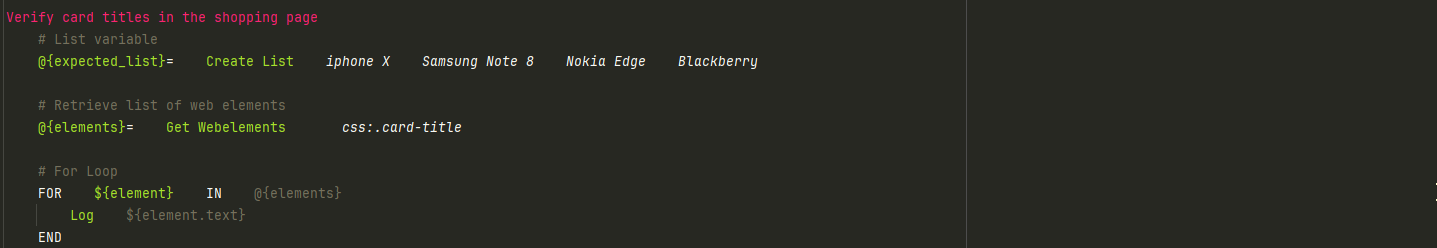

# Using Collections Library

Import **Collections** library as:
```
*** Settings ***
Library              Collections
```

---

```
Verify card titles in the shopping page
    # List variable
    @{expected_list}=    Create List    iphone X    Samsung Note 8    Nokia Edge    Blackberry

    # Retrieve list of web elements
    @{elements}=    Get Webelements       css:.card-title
    
    # actual list
    @{actual_list}=    Create List    

    # For Loop
    FOR    ${element}  IN    @{elements}
        ${text}=    Get Text    ${element}
        Log    ${text}
        Append To List    ${actual_list}    ${text}
    END

    # Compare expected & actual list
    Lists Should Be Equal    ${expected_list}    ${actual_list}
```

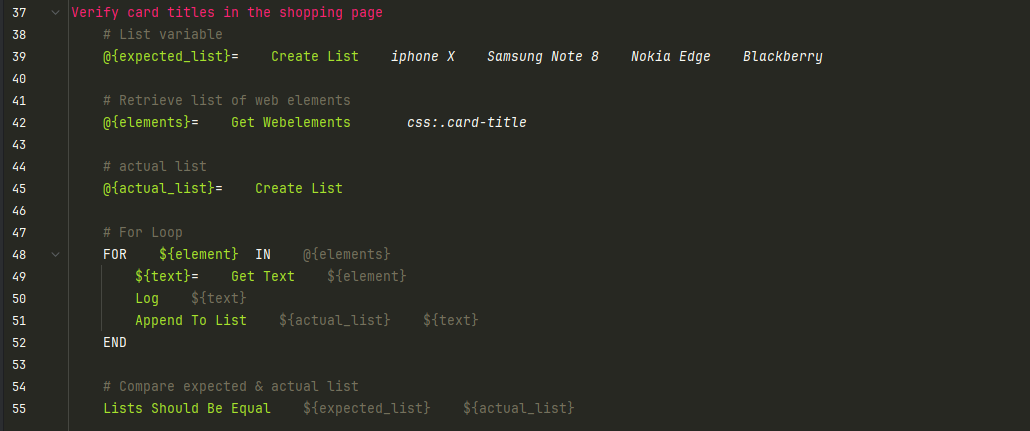

# Generating Dynamic Locator

```
Select the Card
    [arguments]    ${card_name}

    # Retrieve list of web elements
    @{elements}=    Get Webelements       css:.card-title

    # Variable assignment
    ${index}=    Set Variable    1
    
    # Find the index of card_name 
    FOR    ${element}  IN    @{elements}
        Exit For Loop If    '${card_name}'=='${element.text}'
        ${index}=     Evaluate    ${index} + 1
    END

    Click Button    xpath:(//*[@class='card-footer'])[${index}]/button
```

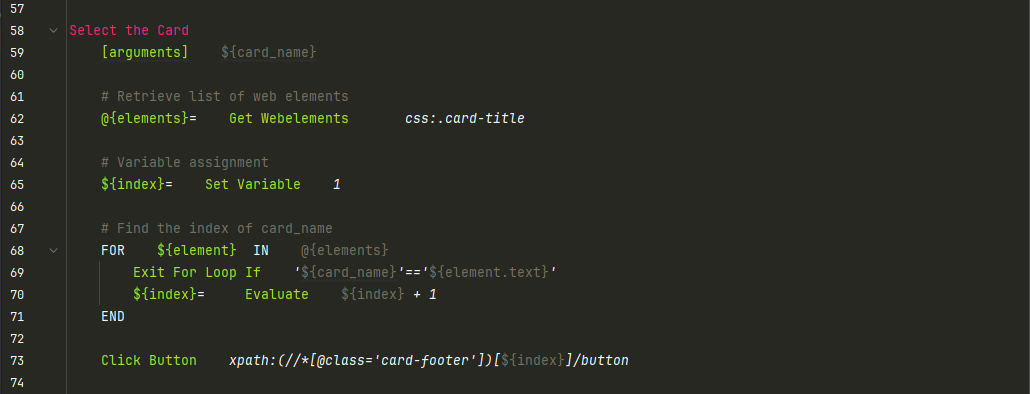

# Handling Dropdowns, Alerts, Checkbox

```
Fill the login details and select the user option
    Input Text            id:username    rahulshettyacademy
    Input Password        id:password    learning

    # Click Radio option
    Click Element         css:input[value='user']

    # Alert/Popup
    Wait Until Element Is Visible    css:.modal-body
    Click Element         okayBtn
    Wait Until Element Is Not Visible    css:.modal-body

    # Select Dropdown
    Wait Until Element Is Visible    css:select.form-control
    Select From List By Value    css:select.form-control     teach

    # Select Checkbox
    Select Checkbox    terms
    Checkbox Should Be Selected    terms

    Click Button          signInBtn
```

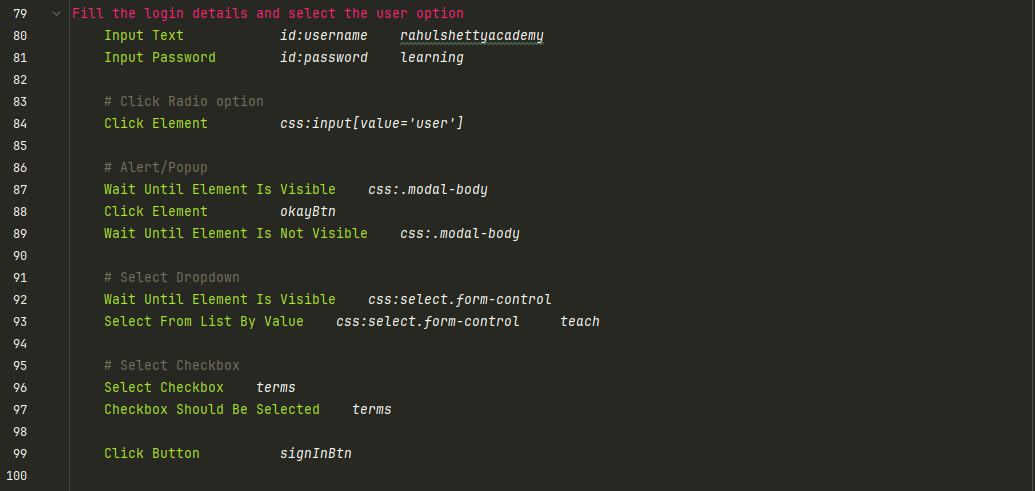

# Handling Child Windows

```
*** Settings ***
Documentation        To validate the login form
Library              SeleniumLibrary                                    # importing SeleniumLibrary
Library              Collections
Library              String
Test Setup           open the browser with the mortgage payment url     # Test Setup executes before the script execution for test set up
Test Teardown        Close Browser                                      # Test Teardown executes after the script execution for cleanup
Resource             resource.robot

*** Test Cases ***

Validate child window functionality
    Select the link of child window
    Verify that the user is switched to child window
    Grab the email id in the child window
    Switch to parent window and enter the email

*** Keywords ***

Select the link of child window
    Click Element    css:.blinkingText
    Sleep    5

# Switch to child window
Verify that the user is switched to child window
    Switch Window    NEW
    Element Text Should Be    css:h1    DOCUMENTS REQUEST

Grab the email id in the child window
    ${text}=    Get Text    css:.red
    @{words} =    Split String     ${text}
    ${email}=    Get From List    ${words}    4
    Log    ${email}
    Set Global Variable    ${email}            # Making local variable Global

# Switch to Parent window
Switch to parent window and enter the email
    Switch Window    MAIN
    Title Should Be    LoginPage Practise | Rahul Shetty Academy
    Input Text     id:username    ${email}
```

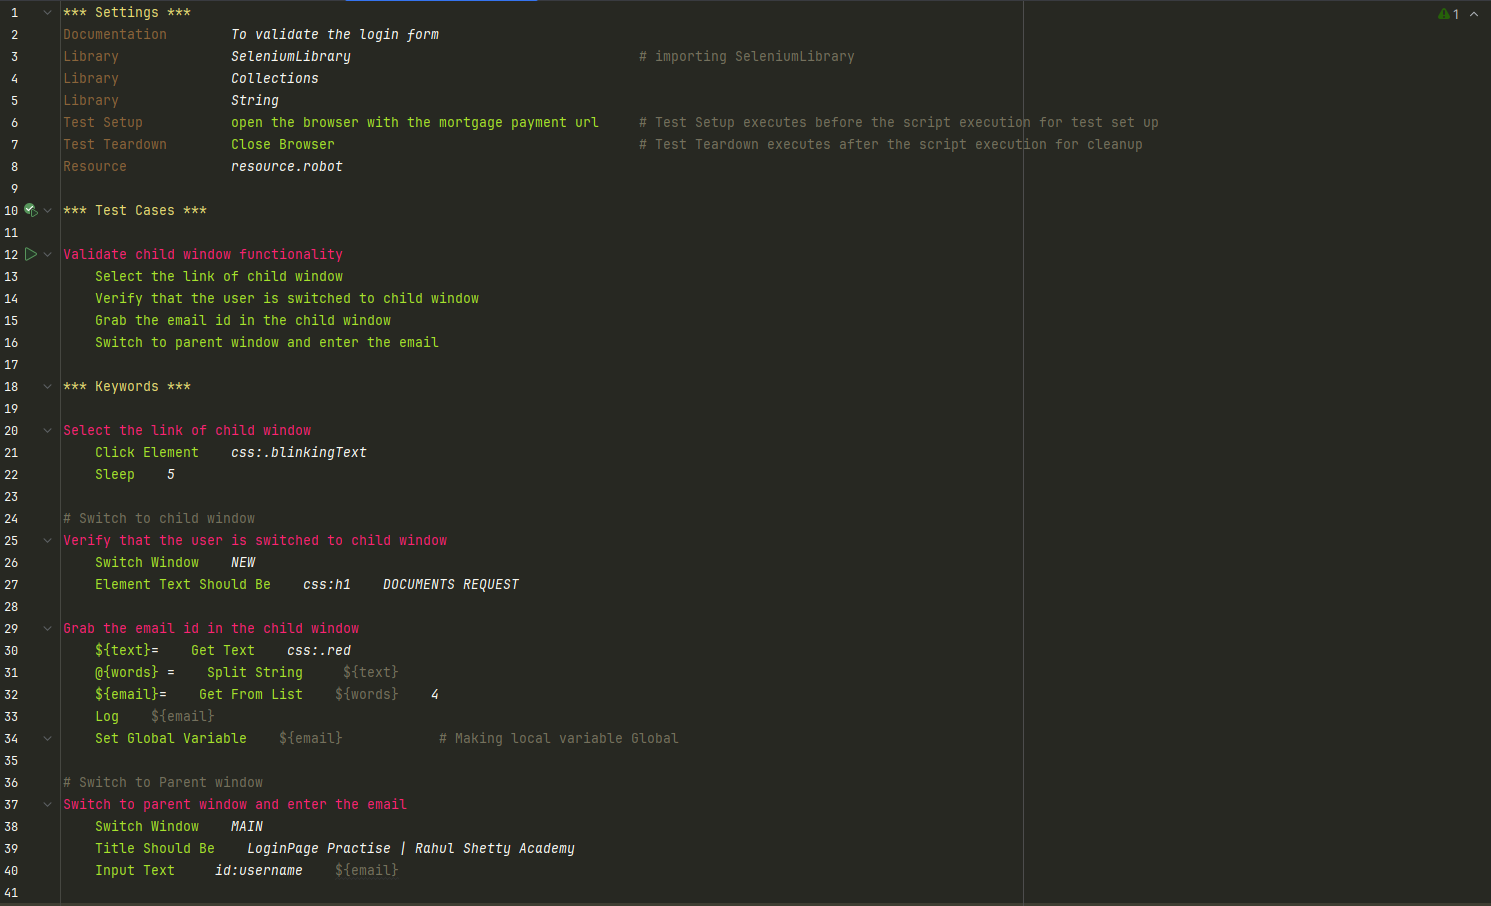